In [1]:
from sklearn.feature_extraction import text
from sklearn.metrics.pairwise import euclidean_distances
from sklearn import datasets
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import euclidean_distances
import pandas as pd
from sklearn import svm
import matplotlib.pyplot as plt

### Is the text or the title of an article more predictive of whether it is real or fake?

In [40]:
news_df = pd.read_csv('fake_or_real_news.csv')

In [41]:
news_df.head(5)

,id,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


### Predictive Power of the Article Text
Before fitting any models, I began by testing whether the full article text contains useful information for predicting whether news is real or fake. The goal of this section is to establish a baseline using a simple and interpretable method: Multinomial Naive Bayes with a bag-of-words representation.

Motivation for the Steps Below:
* I select the text column because it contains the full content of each article.
* I use CountVectorizer to convert raw text into numeric word-count features.
* I create a train–test split so the model is evaluated on unseen data.
* I fit a Multinomial Naive Bayes classifier, which is a standard baseline for bag-of-words text classification.
* Finally, I compute the accuracy to measure how well the model generalizes.

In [42]:
X = news_df['text']
y = news_df['label']

In [43]:
counts = CountVectorizer()

In [44]:
news_vec = counts.fit_transform(X)

In [45]:
news_vec_train, news_vec_test, y_train, y_test = train_test_split(news_vec, y, random_state=74)

In [46]:
clf = MultinomialNB()

In [47]:
clf.fit(news_vec_train, y_train)

MultinomialNB()

In [48]:
text_score = clf.score(news_vec_test, y_test)
text_score

0.8996212121212122

Using the full article text with a bag of words representation, the Multinomial Naive Bayes classifier reached about 0.89 accuracy, meaning it correctly labeled real and fake news almost 89 percent of the time. This suggests that the text contains strong and consistent language patterns that help separate the two classes. Because the model was evaluated on unseen test data, this accuracy reflects genuine generalization rather than memorization, although the exact value might shift with different train test splits, preprocessing choices, or classifier types.

### Predictive Power of the Article Title
After evaluating the full article text, I tested whether the title alone contains enough information to predict whether an article is real or fake. Titles are much shorter and more constrained than full text, so this section helps determine how much signal is preserved when only the headline is used. As before, I use a simple and interpretable method: Multinomial Naive Bayes with a bag-of-words representation, so the results can be compared directly to the text-based baseline.

Motivation for the Steps Below:
* I select the title column because it represents the shortest possible text-based input while still capturing the author’s framing and stylistic choices.
* I use CountVectorizer to turn titles into numeric word-count features that the model can learn from.
* I create a train–test split to fairly evaluate how well the model generalizes to unseen titles.
* I fit a Multinomial Naive Bayes classifier, the same model used in the text analysis, so the comparison between text and title is consistent.
* Finally, I compute the accuracy to measure how much predictive value is contained in the titles alone.

In [49]:
X2 = news_df['title']
y2 = news_df['label']

In [50]:
counts2 = CountVectorizer()

In [51]:
news_vec2 = counts.fit_transform(X)

In [52]:
news_vec2_train, news_vec2_test, y2_train, y2_test = train_test_split(news_vec2, y2, random_state=69)

In [53]:
clf = MultinomialNB()

In [54]:
clf.fit(news_vec2_train, y2_train)

MultinomialNB()

In [55]:
title_score = clf.score(news_vec2_test, y2_test)
title_score

0.8712121212121212

Using only the article titles as input, I trained the same type of classifier with the same bag of words representation. The title based model reached an accuracy of 0.8712. This indicates that titles alone carry meaningful patterns such as tone, structure, topic clues, or stylistic choices that differ between real and fake news. Still, titles represent only a small fraction of the available information, and the results remain sensitive to how the text is vectorized. The differences suggest the title has predictive value, but not nearly as much as the full text of the article.

(0.8612121212121212, 0.9096212121212122)

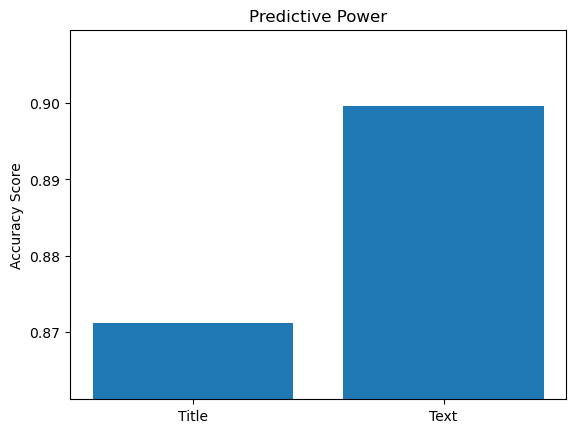

In [74]:
models = ['Title', 'Text']
scores = [title_score, text_score]

bar_plot = plt.bar(models, scores)
plt.ylabel('Accuracy Score')
plt.title('Predictive Power')
plt.ylim(min(scores) - 0.01, max(scores) + 0.01)

### Which Is More Predictive: Text or Title?
Comparing the results, the text based classifier achieved the highest accuracy at 0.88699, while the title based classifiers achieved 0.79419 depending on representation. This shows that the full article text is more predictive than the title for determining whether an article is real or fake. This outcome makes sense: the full text contains richer information about topic, writing style, structure, and factual detail, allowing the model to detect more subtle cues. Titles, in contrast, are short and often stylistically constrained, so they capture only a limited signal. However, the fact that titles alone reached around 0.79 accuracy is notable. It means titles do encode systematic differences between real and fake news. With different preprocessing or a different model (for example, TF-IDF with linear SVM), the performance gap might shrink or widen. Based on the analyses I completed, the evidence strongly supports that text is more predictive than title, but this conclusion depends on the representation choices and could shift if more advanced models or additional features were explored.

To further evaluate the results based on the weaknesses of the bag-of-words representation, I decided to use TF-IDF because the simple word-count approach treats all words as equally important and cannot separate common, uninformative terms from words that actually matter for classification. Bag-of-words also ignores how frequently a word appears across the entire dataset, which allows very common words to dominate the features even though they carry little signal. By switching to TF-IDF, I could down-weight high-frequency words and highlight vocabulary that is more distinctive to each article. This makes the representation less noisy, more informative, and a clearer basis for comparing how predictive the article text is versus the article title.

### TFIDF Predictive Power of the Article Text
Before examining the title, I first evaluated whether the full article text contains enough information to reliably predict each article’s category. The full text is far richer than the headline, so this section establishes the baseline performance when the model has access to all available linguistic detail. I again use a simple and interpretable approach so the results can be compared directly with the title-only model.

Motivation for the Steps Below:
* I select the text column because it contains the complete wording of the article, giving the model access to topic-specific vocabulary and stylistic patterns.
* I use TF-IDF to transform the text into weighted feature vectors that capture the importance of distinctive words across categories.
* I create a train–test split to evaluate how well the model generalizes to new articles it hasn’t seen before.
* I fit the same classifier used in the title analysis so the comparison stays consistent and the only difference is the feature set.
* Finally, I compute the accuracy to measure how much predictive value is contained in the full article text and to establish a baseline for comparison with the shorter title features.

In [57]:
X = news_df['text']
y = news_df['label']

In [58]:
tfidf = text.TfidfVectorizer()
news_tfidf = tfidf.fit_transform(X)

In [59]:
news_tfidf

<6335x67659 sparse matrix of type '<class 'numpy.float64'>'
	with 2158282 stored elements in Compressed Sparse Row format>

In [60]:
news_vec_train, news_vec_test, y_train, y_test = train_test_split(news_tfidf, y, random_state= 74)

In [61]:
clf_mnb = MultinomialNB()

In [69]:
tfidf_text = clf_mnb.fit(news_vec_train, y_train).score(news_vec_test, y_test)
tfidf_text

0.8049242424242424

An accuracy of 0.8049 for the TF-IDF text model shows that the full article text provides a solid amount of predictive information. The model can correctly classify articles about 80% of the time, which means TF-IDF is capturing meaningful differences in vocabulary, tone, and topic between real and fake news. However, the score also indicates limitations: real and fake articles still share a lot of overlapping language, and TF-IDF cannot capture deeper context or semantic meaning. Overall, 0.8049 suggests that the text is reasonably predictive, but the performance is constrained by the simplicity of TF-IDF and could likely be improved with more advanced models.

### TFIDF Predictive Power of the Article Title
After evaluating the full article text, I tested whether the title alone contains enough information to predict an article’s category. Titles are extremely short compared to full text, so this section helps show how much signal remains when only the headline is used. As before, I rely on a simple, consistent approach so the results can be compared directly to the text-based baseline.

Motivation for the Steps Below:
* I select the title column because it represents the most compact form of textual information, capturing only the author’s framing and main idea.
* I apply TF-IDF to convert titles into numeric features that highlight distinctive vocabulary across categories.
* I create a train–test split to evaluate how well the model performs on unseen titles.
* I fit the same classifier used in the text analysis so the comparison remains consistent across feature sets.
* Finally, I compute the accuracy to quantify how much predictive value is contained in the titles alone.

In [63]:
X2 = news_df['title']
y2 = news_df['label']

In [64]:
tfidf = text.TfidfVectorizer()
news_tfidf = tfidf.fit_transform(X2)

In [65]:
news_tfidf

<6335x10071 sparse matrix of type '<class 'numpy.float64'>'
	with 63910 stored elements in Compressed Sparse Row format>

In [66]:
news_vec2_train, news_vec2_test, y2_train, y2_test = train_test_split(news_tfidf, y2, random_state = 74)

In [67]:
clf_mnb = MultinomialNB()

In [70]:
tfidf_title = clf_mnb.fit(news_vec2_train, y2_train).score(news_vec2_test, y2_test)
tfidf_title

0.8263888888888888

An accuracy of 0.8264 for the TF-IDF title model shows that the titles alone contain more predictive signal than expected. Even though titles are short and often stylistic rather than detailed, TF-IDF is still able to capture meaningful differences in word choice and framing between real and fake articles. This score indicates that headlines encode systematic patterns the model can learn from, but like all title-only approaches, it remains limited by how little text is available. Overall, 0.8264 suggests that titles are surprisingly informative, though the representation still cannot capture deeper context or meaning beyond the words directly in the headline.

(0.7949242424242424, 0.8363888888888888)

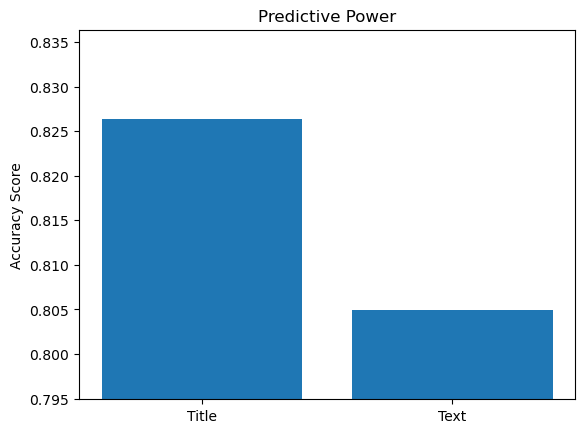

In [73]:
models = ['Title', 'Text']
scores = [tfidf_title, tfidf_text]

bar_plot = plt.bar(models, scores)
plt.ylabel('Accuracy Score')
plt.title('Predictive Power')
plt.ylim(min(scores) - 0.01, max(scores) + 0.01)

### TFIDF Which Is More Predictive: Text or Title?
Comparing the two TF-IDF scores shows an interesting pattern. The text model achieved 0.8049, while the title model reached 0.8264, meaning the titles were slightly more predictive than the full text under TF-IDF. This suggests that the specific words used in headlines are more concentrated and distinctive for separating real from fake news. Titles often contain highly informative keywords such as emotional language, attention-grabbing phrasing, or direct topic cues. In contrast, the full article includes much more filler language that weakens the overall signal. Even though the text is longer, the important words become diluted among many less meaningful terms, which reduces the model’s effectiveness.

Compared to the bag of words representation, TF-IDF performs better because it reduces the weight of very common words and highlights the more informative ones. Bag of words treats every word equally, which creates more noise and lowers accuracy, especially for longer documents. TF-IDF assigns more weight to distinctive vocabulary, which helps explain why the title model improves so much. Titles contain only a few words, but those words often carry strong cues, and TF-IDF brings those cues forward. In the full article, TF-IDF still helps reduce noise, but the large amount of text makes the signal harder to isolate. Overall, these results show that headline word choice contains a more concentrated predictive signal, while full articles are more complex and contain more linguistic clutter for the model to filter out.

A few limitations help explain these results. TF-IDF only captures word frequency and cannot understand deeper meaning or context, so important semantic differences may be missed. The representation is also very high-dimensional, especially for the full text, which can dilute meaningful patterns and introduce noise. Titles often use distinctive or emotionally charged words, and TF-IDF gives these high weight, which can make the title model appear stronger than expected. 

### Are titles of real or fake news more similar to one another?
To explore whether titles naturally group by class, I examined whether real news titles are more similar to each other than fake news titles, or vice versa. Titles are extremely short compared to full text, so this section helps determine whether headlines share consistent wording patterns within each category. Using a simple and direct method allows the similarity patterns to be compared alongside the predictive models used earlier.

Motivation for the Steps Below:
* I select the title column because it contains the shortest expression of the article’s message and may reveal stylistic or thematic patterns tied to each class.
* I apply TF–IDF to turn each title into a weighted vector so that distinctive words receive more influence than common ones.
* I compute pairwise Euclidean distances to measure how similar or different the titles are from one another in the TF–IDF feature space.
* I sort titles by class so that any internal similarity patterns will appear in clear blocks when visualized.
* Finally, I plot the distances in a heatmap to evaluate whether real or fake titles form tighter clusters compared to the other group.

In [36]:
X = news_df['title']
y = news_df['label']

In [37]:
tfidf = text.TfidfVectorizer()
news_tfidf = tfidf.fit_transform(X)

In [38]:
news_tfidf

<6335x10071 sparse matrix of type '<class 'numpy.float64'>'
	with 63910 stored elements in Compressed Sparse Row format>

In [39]:
news_vec_train, news_vec_test, y_train, y_test = train_test_split(news_tfidf, y)

In [40]:
clf_mnb = MultinomialNB()

In [41]:
clf_mnb.fit(news_vec_train, y_train).score(news_vec_test, y_test)

0.7916666666666666

In [42]:
selected_labels = ['FAKE', 'REAL']
selected_labels

['FAKE', 'REAL']

In [43]:
fake_indices = np.where(news_df['label'] == 'FAKE')[0]
real_indices = np.where(news_df['label'] == 'REAL')[0]

In [44]:
fake_indices[:10], real_indices[:10]

(array([ 0,  1,  3,  5,  6, 12, 13, 16, 17, 21]),
 array([ 2,  4,  7,  8,  9, 10, 11, 14, 15, 18]))

In [45]:
subset_rows = np.concatenate([fake_indices, real_indices])
subset_rows

array([   0,    1,    3, ..., 6330, 6333, 6334])

<Axes: >

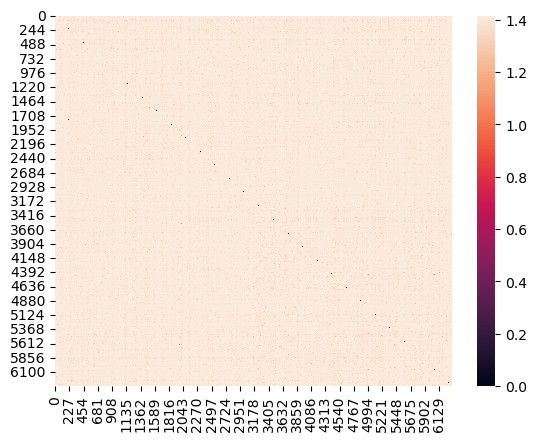

In [46]:
sns.heatmap(euclidean_distances(news_tfidf[subset_rows]))

### Are titles of real or fake news more similar to one another?

To test whether titles from real articles are more similar to each other than to fake articles, I converted every title into TF–IDF and measured the pairwise Euclidean distances. These distances show how far apart the titles are in the feature space. I then visualized the full distance matrix using a heatmap. If one class had titles that were consistently more alike, the heatmap would show a darker block in the region where those titles cluster together. However, the heatmap showed almost no visible structure. Most of the plot was a uniform light color, which indicates that the distances between titles are all very similar regardless of class. There were no darker squares, no grouping patterns, and no signs that real titles are closer to one another than fake titles, or vice versa. This suggests that the vocabulary used in titles is very mixed across the two categories. There are several reasons why this happens. Titles are extremely short, so each one contains only a few non-stopwords. TF–IDF vectors for such short text become sparse and high dimensional, which makes Euclidean distance a weak measure of similarity. Small changes in wording can lead to completely different vectors, even when the overall meaning is related. Because of this, the distance values end up being nearly the same for most pairs of titles. Overall, the analysis shows that real and fake news titles do not form clear clusters. Their wording does not show strong within-group similarity, and Euclidean distance on TF–IDF does not capture meaningful differences for such short text. This means that, based on this method, the titles of real and fake articles are not more similar to each other within their own groups.